# Diode Bayesian Inference with UltraNest


In [1]:
import copy
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
plt.style.use('default')

try:
    from optimpv import *
    from optimpv.models.Diodefits.DiodeAgent import DiodeAgent
    from optimpv.models.Diodefits.DiodeModel import NonIdealDiode_dark
    from optimpv.optimizers.BayesInfUltraNest.UltraNestOptimizer import UltraNestOptimizer
except Exception:
    sys.path.append('../')
    from optimpv import *
    from optimpv.models.Diodefits.DiodeAgent import DiodeAgent
    from optimpv.models.Diodefits.DiodeModel import NonIdealDiode_dark
    from optimpv.optimizers.BayesInfUltraNest.UltraNestOptimizer import UltraNestOptimizer


## Problem Setup


In [2]:
params = []

J0 = FitParam(name = 'J0', value = 1e-5, bounds = [1e-6,1e-3], log_scale = True, rescale = False, value_type = 'float', type='range', display_name=r'$J_0$', unit='A m$^{-2}$', axis_type = 'log',force_log=True)
params.append(J0)

n = FitParam(name = 'n', value = 1.5, bounds = [1,2], log_scale = False, value_type = 'float', type='range', display_name=r'$n$', unit='', axis_type = 'linear')
params.append(n)

R_series = FitParam(name = 'R_series', value = 1e-4, bounds = [1e-5,1e-3], log_scale = True, rescale = False, value_type = 'float', type='range', display_name=r'$R_{\text{series}}$', unit=r'$\Omega$ m$^2$', axis_type = 'log',force_log=True)
params.append(R_series)

R_shunt = FitParam(name = 'R_shunt', value = 1e-1, bounds = [1e-2,1e2], log_scale = True, rescale = False, value_type = 'float', type='range', display_name=r'$R_{\text{shunt}}$', unit=r'$\Omega$ m$^2$', axis_type = 'log',force_log=True)
params.append(R_shunt)

# original values
params_orig = copy.deepcopy(params)
num_free_params = len([p for p in params if p.type != 'fixed'])


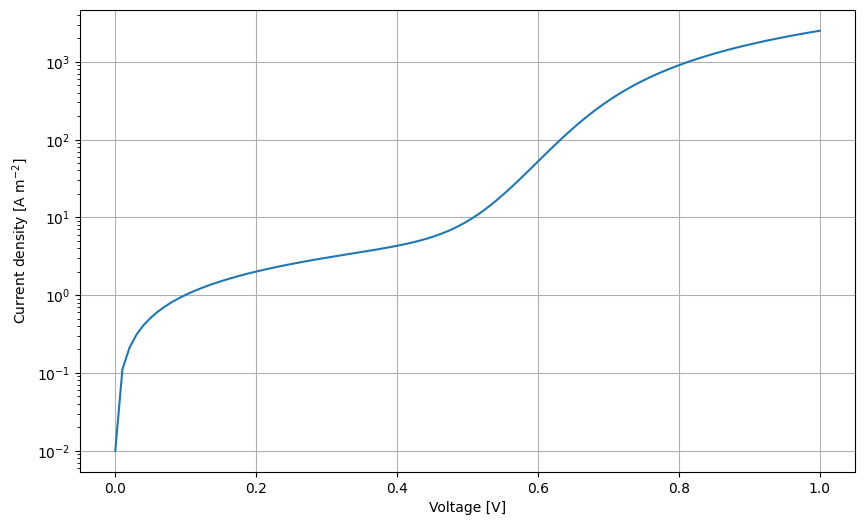

In [3]:
# Create JV to fit
X = np.linspace(0.001,1,100)
y = NonIdealDiode_dark(X, J0.value, n.value, R_series.value, R_shunt.value)

plt.figure(figsize=(10,6))
plt.semilogy(X,y)
plt.xlabel('Voltage [V]')
plt.ylabel('Current density [A m$^{-2}$]')
plt.grid()
plt.show()


In [4]:
# Define the Agent and the target metric/loss function
metric = 'mse' # can be 'nrmse', 'mse', 'mae'
loss = 'linear' # can be 'linear', 'huber', 'soft_l1'
exp_format = 'dark' # can be 'dark', 'light' depending on the type of data you have
use_pvlib = False # if True, use pvlib to calculate the diode model if not use the implementation in DiodeModel.py
diode = DiodeAgent(params, X, y, metric = metric, loss = loss, minimize=True,exp_format=exp_format,use_pvlib=use_pvlib,transforms='linear')

## Run UltraNest

If `ultranest` is not installed in the environment, the next cell will fail with an import error from the optimizer.


In [5]:

optimizer = UltraNestOptimizer(
    params=params,
    agents=diode,
    progress=True,
    log_dir='ultranest_logs/diode',
    resume='subfolder', # can be True, False, 'subfolder', or 'overwrite'
    name='diode',
    save_logs=False,
    run_kwargs={
        'min_num_live_points': 400,
        'dlogz': 0.5, 
        'min_ess': 100 
        # 'max_ncalls': 57600,
    },
)

results = optimizer.optimize()
optimizer.sampler.print_results()
best_params = optimizer.get_best_params(method='max_likelihood')
results


[INFO 04-24 12:52:17] optimpv.UltraNestOptimizer: Running UltraNest nested sampling...


----------------------------------------------------

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-3e+05  ..-334742.86 [-334742.9439..-334742.9437]*| it/evals=2640/4868 eff=59.0868% N=400 
[ultranest] Likelihood function evaluations: 4884
[ultranest]   logZ = -3.347e+05 +- 0.03505
[ultranest] Effective samples strategy satisfied (ESS = 1644.3, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.05 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.04, need <0.5)
[ultranest]   logZ error budget: single: 0.05 bs:0.04 tail:0.01 total:0.04 required:<0.50
[ultranest] done iterating.


[INFO 04-24 12:52:32] optimpv.UltraNestOptimizer: UltraNest run complete.
[INFO 04-24 12:52:32] optimpv.UltraNestOptimizer: $J_0$ (J0): 2.858e-05 (+0.000282 / -2.57e-05)
[INFO 04-24 12:52:32] optimpv.UltraNestOptimizer: $n$ (n): 1.101 (+0.186 / -0.0731)
[INFO 04-24 12:52:32] optimpv.UltraNestOptimizer: $R_{\text{series}}$ (R_series): 8.263e-05 (+0.000278 / -6.39e-05)
[INFO 04-24 12:52:32] optimpv.UltraNestOptimizer: $R_{\text{shunt}}$ (R_shunt): 0.7195 (+20.4 / -0.681)


----------------------------------------------------


logZ = -334744.933 +- 0.069
  single instance: logZ = -334744.933 +- 0.047
  bootstrapped   : logZ = -334744.930 +- 0.068
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    J0                  : -6.00 │▇▆▆▆▇▅▅▅▅▅▆▇▆▆▇▇▇▆▆▇▆▄▅▅▆▅▆▇▅▅▆▆▇▅▆▅▄▇▅│-3.00     -4.52 +- 0.87
    n                   : 1.00  │▇▇▆▅▃▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▁  ▁▁│2.00      1.15 +- 0.15
    R_series            : -5.00 │▆▆▆▇▆▅▆▇▄▆▆▆▅▅▆▇▆▆▆▇▆▅▆▅▆▆▆▄▆▆▅▄▄▆▆▃▃▄▃│-3.00     -4.07 +- 0.55
    R_shunt             : -2.0  │▆▆▆▅▇▇▆▆▇▇▆▆▅▇▅▅▅▅▆▆▅▆▄▄▆▅▅▄▅▆▆▆▄▆▆▄▆▅▆│2.0       -0.1 +- 1.2



{'J0': {'median': np.float64(2.8577476813298173e-05),
  '16th': np.float64(2.8305084875799895e-06),
  '84th': np.float64(0.00031029691970053903),
  'lower_err': np.float64(2.5746968325718183e-05),
  'upper_err': np.float64(0.00028171944288724087)},
 'n': {'median': np.float64(1.1009021336170912),
  '16th': np.float64(1.0278508844480407),
  '84th': np.float64(1.2872757413468414),
  'lower_err': np.float64(0.07305124916905048),
  'upper_err': np.float64(0.1863736077297502)},
 'R_series': {'median': np.float64(8.26308528860354e-05),
  '16th': np.float64(1.8700293239762995e-05),
  '84th': np.float64(0.00036100702272542424),
  'lower_err': np.float64(6.39305596462724e-05),
  'upper_err': np.float64(0.00027837616983938886)},
 'R_shunt': {'median': np.float64(0.7195440781626201),
  '16th': np.float64(0.0389450007197354),
  '84th': np.float64(21.16600182082982),
  'lower_err': np.float64(0.6805990774428847),
  'upper_err': np.float64(20.4464577426672)}}

In [6]:
summary_rows = []
for param in params:
    if param.type == 'fixed':
        continue
    summary_rows.append({
        'parameter': param.name,
        'best_fit': best_params[param.name],
        'posterior_median': results[param.name]['median'],
        '16th_percentile': results[param.name]['16th'],
        '84th_percentile': results[param.name]['84th'],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,parameter,best_fit,posterior_median,16th_percentile,84th_percentile
0,J0,0.000408,0.000029,0.000003,0.000310
1,n,1.000275,1.100902,1.027851,1.287276
2,R_series,0.000012,0.000083,0.000019,0.000361
3,R_shunt,0.026077,0.719544,0.038945,21.166002


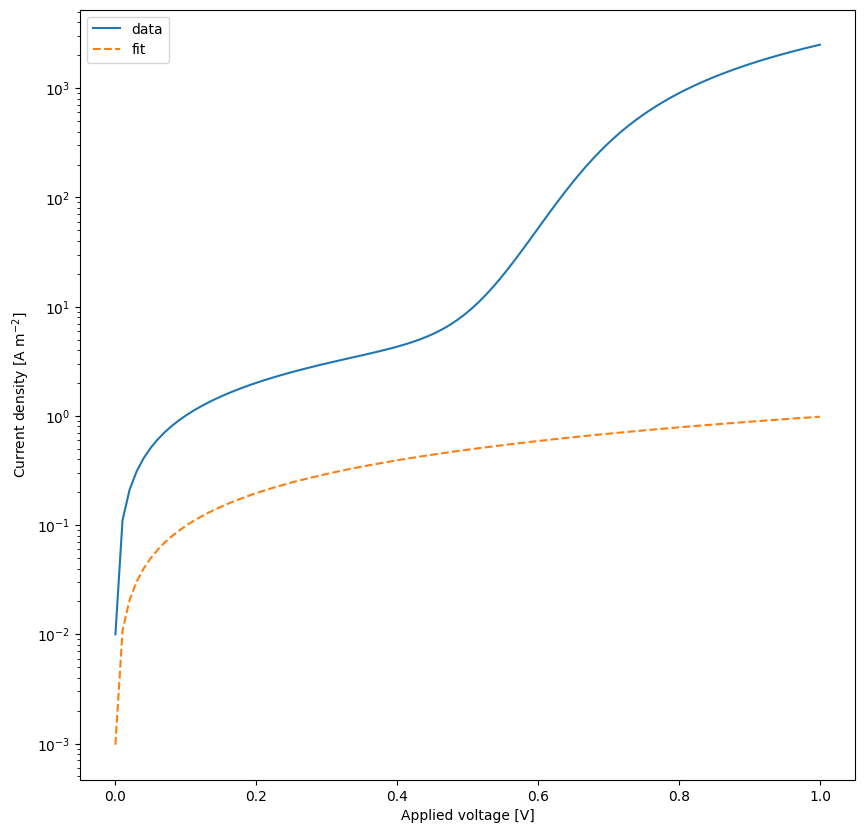

In [7]:
best_fit_agent = DiodeAgent(params, X, y, metric = metric, loss = loss, minimize=True,exp_format=exp_format,use_pvlib=use_pvlib,transforms='log')

yfit = best_fit_agent.run(best_params)

plt.figure(figsize=(10,10))
plt.plot(X,y,label='data')
plt.plot(X,yfit,label='fit',linestyle='--')
plt.xscale('linear')
plt.yscale('log')
plt.xlabel('Applied voltage [V]')
plt.ylabel('Current density [A m$^{-2}$]')
plt.legend()
plt.show()


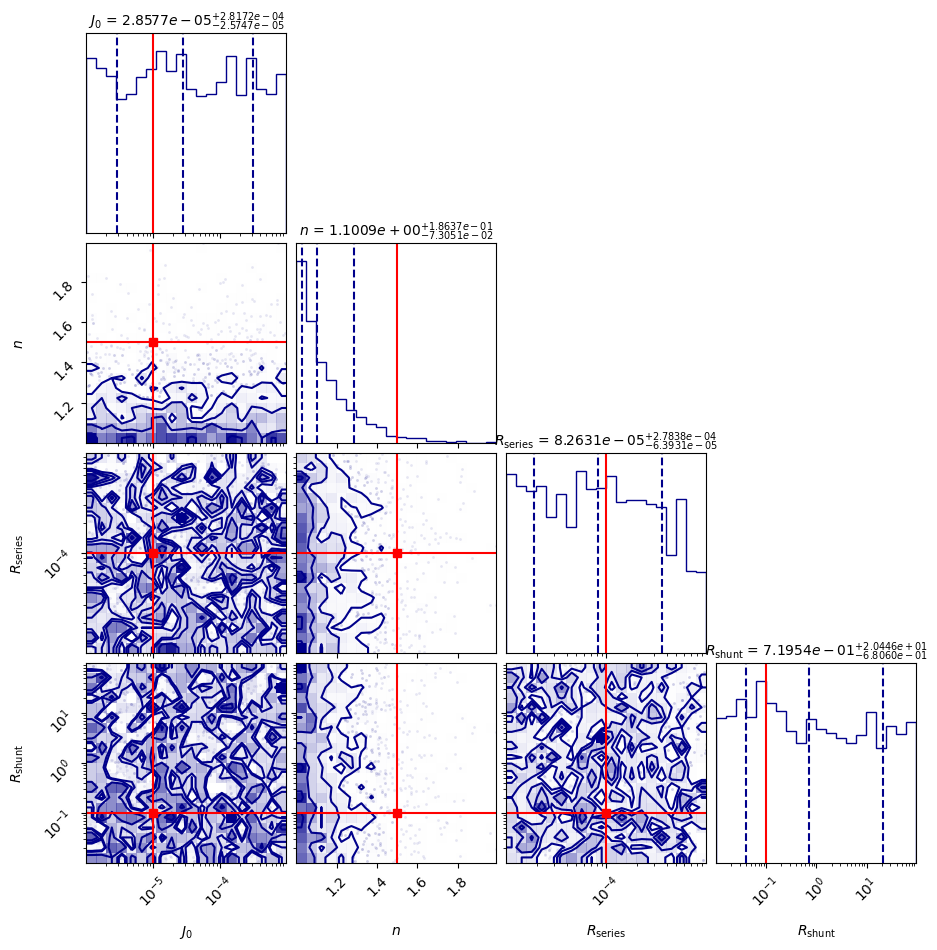

In [8]:
post_params = {param.name: param.value for param in params_orig if param.type != 'fixed'}
fig = optimizer.plot_corner(True_params=post_params)
plt.show()


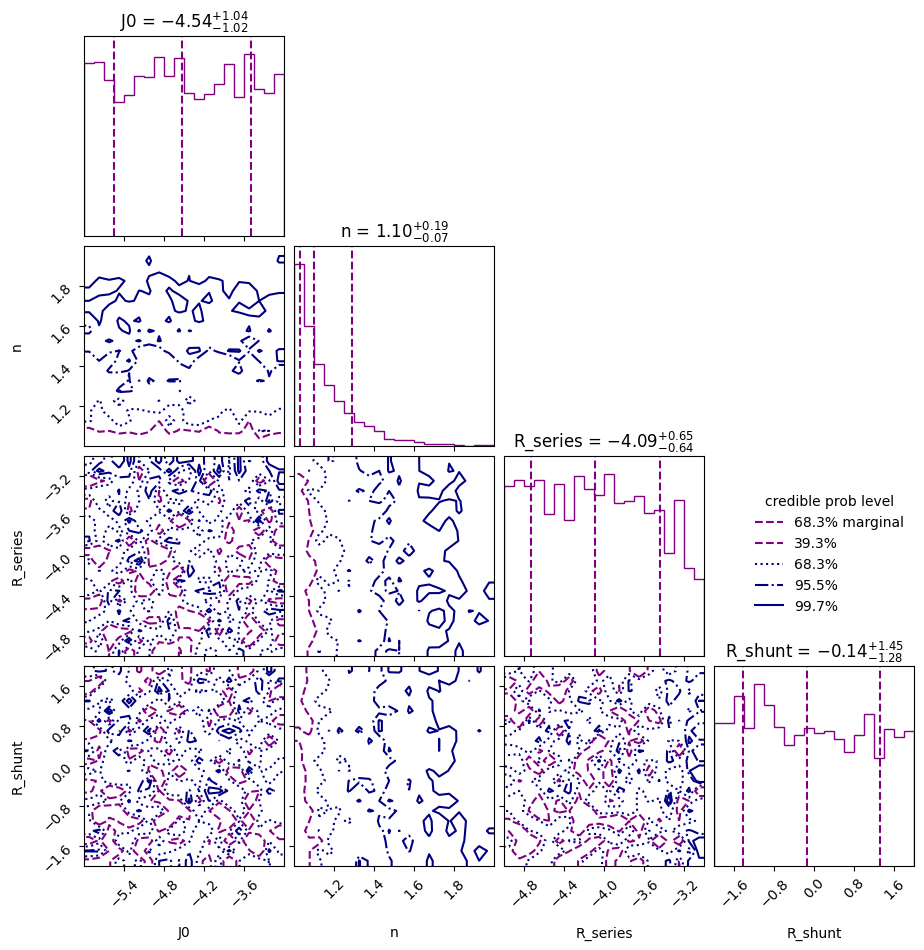

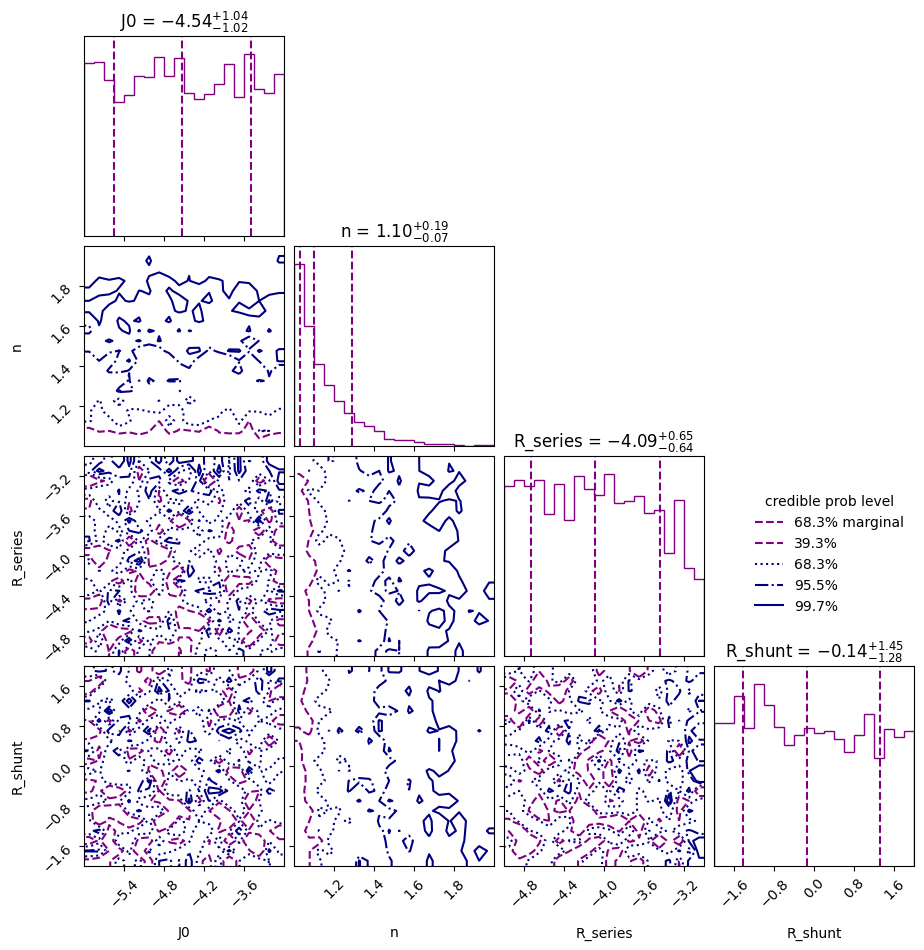

In [9]:
from ultranest.plot import cornerplot
result = optimizer.nested_result
cornerplot(result)


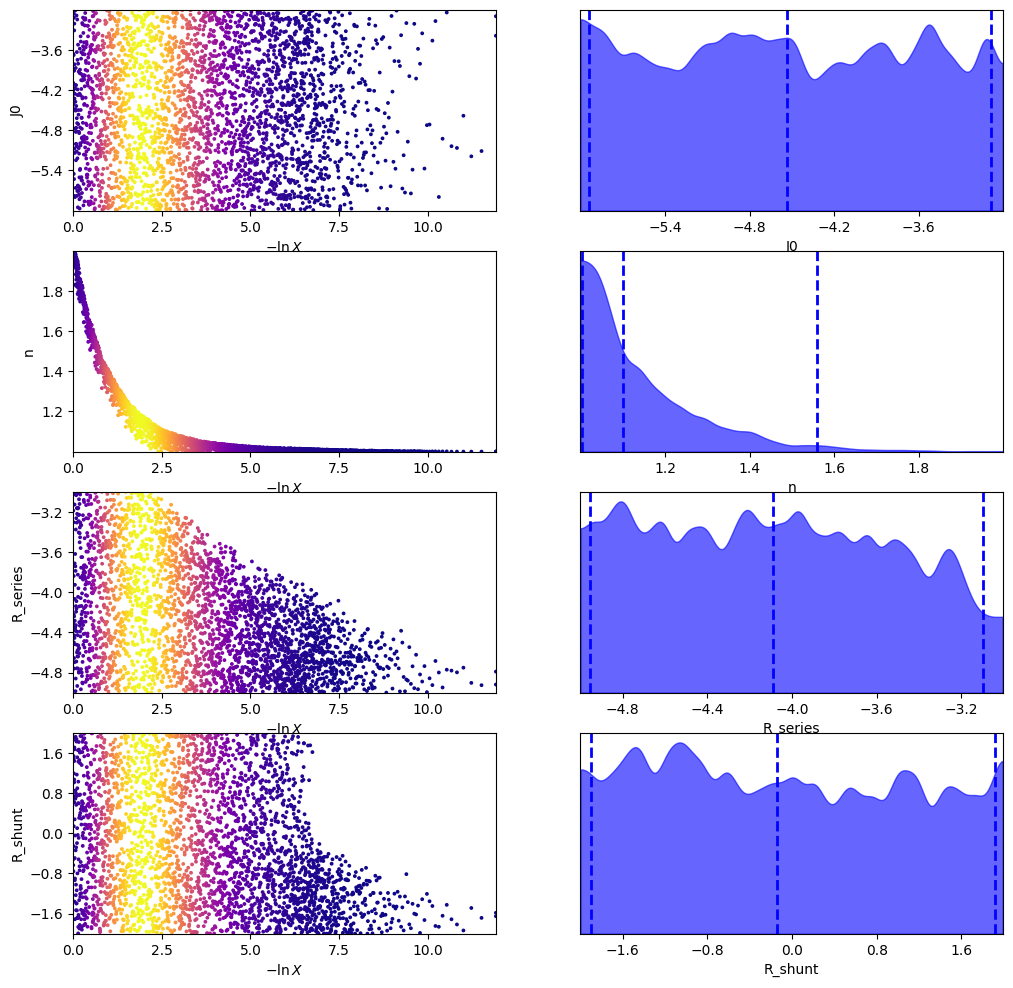

In [10]:
optimizer.sampler.plot_trace()
plt.show()